In [1]:
# Install the YOLOv8 library
!pip install -q ultralytics

import os
import yaml
import glob
from ultralytics import YOLO
from IPython.display import Image, display

print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.4 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully!


In [2]:
# The path you provided
dataset_path = "/kaggle/input/datasets/jitinvenkatasai/major-project"

# Let's double-check if the path exists. If Kaggle shortened it, we will catch it here.
if not os.path.exists(dataset_path):
    print(f"Path {dataset_path} not found. Searching for 'major-project'...")
    # Fallback to typical Kaggle path
    dataset_path = "/kaggle/input/major-project" 

print(f"Using dataset path: {dataset_path}")

# Load the original data.yaml
original_yaml_path = os.path.join(dataset_path, "data.yaml")

with open(original_yaml_path, 'r') as file:
    data = yaml.safe_load(file)

# Overwrite the paths to point to absolute Kaggle directories
data['train'] = os.path.join(dataset_path, "train")
data['val'] = os.path.join(dataset_path, "valid")
data['test'] = os.path.join(dataset_path, "test")

# Save the corrected yaml to Kaggle's working directory (which is writable)
working_yaml_path = "/kaggle/working/data.yaml"
with open(working_yaml_path, 'w') as file:
    yaml.dump(data, file, default_flow_style=False)

print(f"New data.yaml created at {working_yaml_path}")
print("Classes to detect:", data.get('names'))

Using dataset path: /kaggle/input/datasets/jitinvenkatasai/major-project
New data.yaml created at /kaggle/working/data.yaml
Classes to detect: ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']


In [3]:
# Load the pre-trained YOLOv8 nano model
model = YOLO('yolov8n.pt')

# Start training! 
# epochs=30 is a good starting point. You can increase it to 50 or 100 later if needed.
# imgsz=640 is the standard resolution for YOLOv8.
# project="Garbage_Detection" will organize our saved files neatly.
results = model.train(
    data=working_yaml_path,
    epochs=30,  
    imgsz=640,
    batch=16,
    project="Garbage_Detection",
    name="run_1",
    seed=42 # Sets a seed for reproducible results
)

print("Training complete! Weights are saved in /kaggle/working/Garbage_Detection/run_1/weights/")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,


📊 Confusion Matrix (See where the model gets confused):


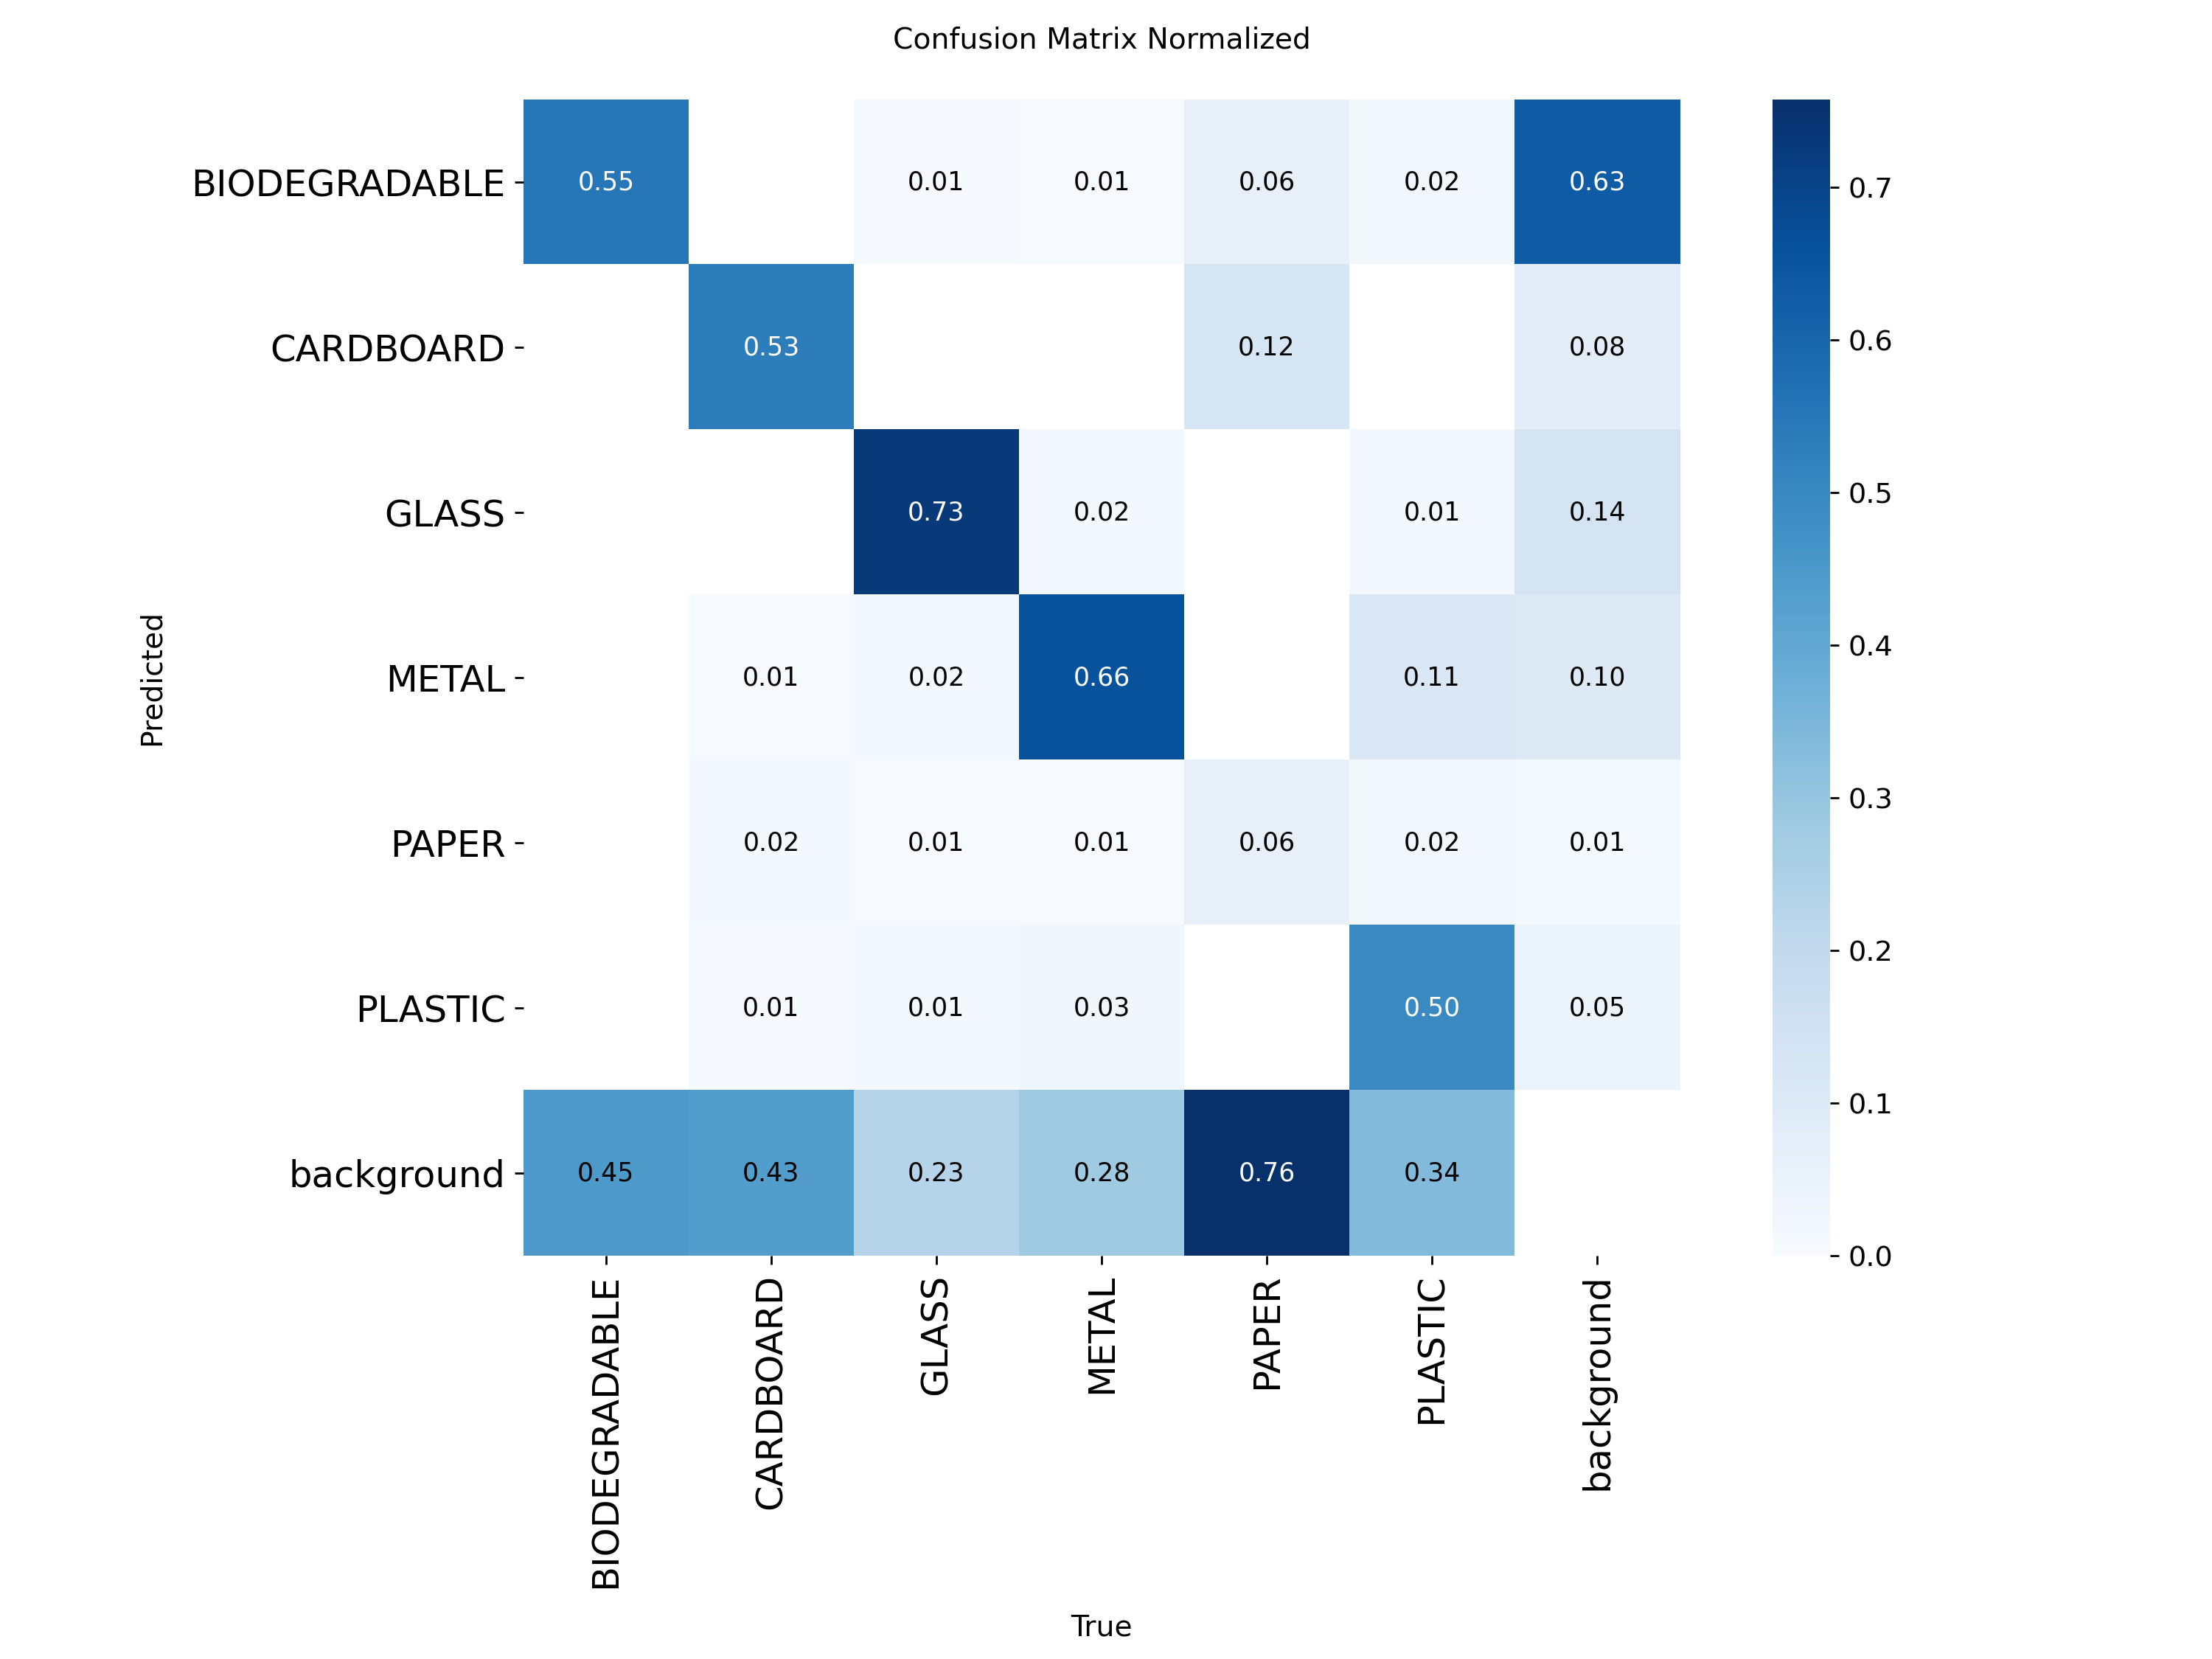


📈 Training Results (Watch the loss drop over time):


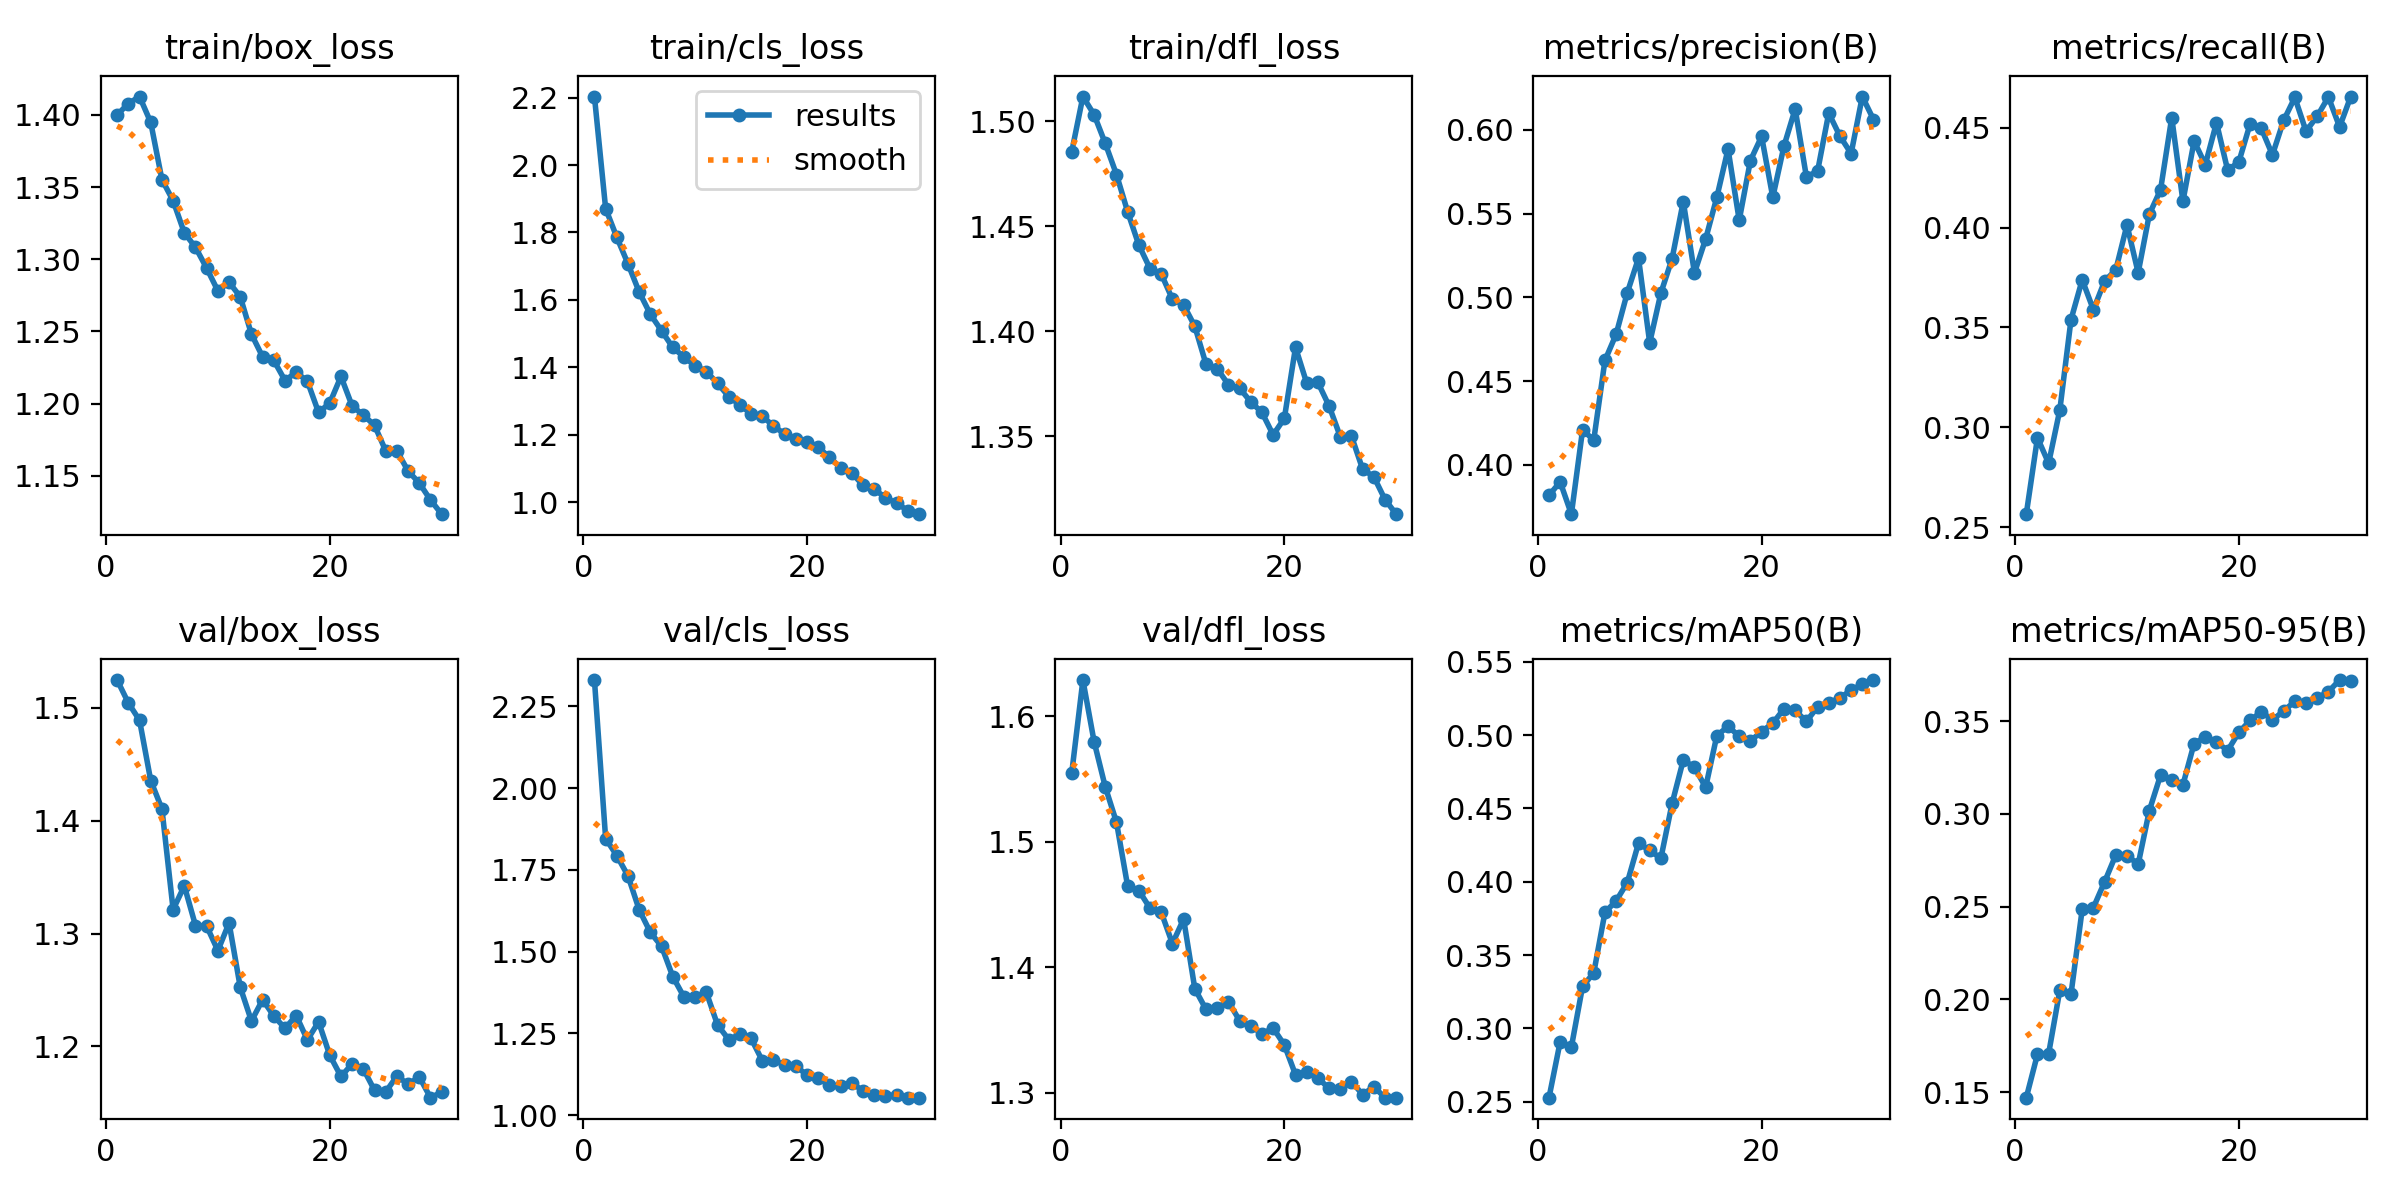

In [7]:
import os
from IPython.display import Image, display

# We now know the EXACT path from your training output
run_dir = "/kaggle/working/runs/detect/Garbage_Detection/run_1"

def show_graph(filename):
    filepath = os.path.join(run_dir, filename)
    if os.path.exists(filepath):
        display(Image(filename=filepath, width=800))
    else:
        print(f"Could not find {filename}")

print("\n📊 Confusion Matrix (See where the model gets confused):")
show_graph("confusion_matrix_normalized.png")

print("\n📈 Training Results (Watch the loss drop over time):")
show_graph("results.png")

In [9]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
from PIL import Image
import numpy as np
import cv2
from ultralytics import YOLO

# 1. Load your newly trained brain!
best_weights = "/kaggle/working/runs/detect/Garbage_Detection/run_1/weights/best.pt"
model = YOLO(best_weights)

# 2. Create the interactive Upload Button
uploader = widgets.FileUpload(
    accept='image/*',  # Accept all image formats like jpg, png
    multiple=False,    # Only allow one image at a time
    description='Upload Image'
)

# 3. Create an output area to show the image
out = widgets.Output()

# 4. Define what happens when you upload an image
def on_upload_change(change):
    with out:
        clear_output() # Clear previous results
        
        if not uploader.value:
            return
            
        print("⏳ Analyzing image...")
        
        # Extract the image data from the upload button
        try:
            # For newer versions of ipywidgets
            uploaded_file = uploader.value[0]
            content = uploaded_file['content']
        except KeyError:
            # For older versions of ipywidgets
            filename = list(uploader.value.keys())[0]
            content = uploader.value[filename]['content']
            
        # Convert the raw bytes into a format YOLO can read
        image = Image.open(io.BytesIO(content)).convert('RGB')
        img_array = np.array(image)
        
        # Run the YOLOv8 prediction
        results = model.predict(source=img_array, conf=0.25)
        
        # Draw the bounding boxes
        res_plot = results[0].plot()
        
        # Convert colors back to standard RGB and display
        res_plot_rgb = cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB)
        final_image = Image.fromarray(res_plot_rgb)
        
        # Resize slightly so it doesn't take up the whole screen
        final_image.thumbnail((600, 600))
        display(final_image)
        print("✅ Done!")

# Watch the upload button for changes
uploader.observe(on_upload_change, names='value')

# Display the UI
print("👇 Click the button below to upload an image from your PC!")
display(uploader, out)

👇 Click the button below to upload an image from your PC!


FileUpload(value=(), accept='image/*', description='Upload Image')

Output()

In [10]:
from IPython.display import FileLink
import os

# The exact path to your best model weights
weights_path = "/kaggle/working/runs/detect/Garbage_Detection/run_1/weights/best.pt"

if os.path.exists(weights_path):
    print("✅ Model found! Click the link below to download:")
    display(FileLink(weights_path))
else:
    print("⚠️ File not found. Double-check the run folder.")

✅ Model found! Click the link below to download:


/kaggle/working/runs/detect/Garbage_Detection/run_1/weights/best.pt


✨ confusion_matrix_normalized.png:


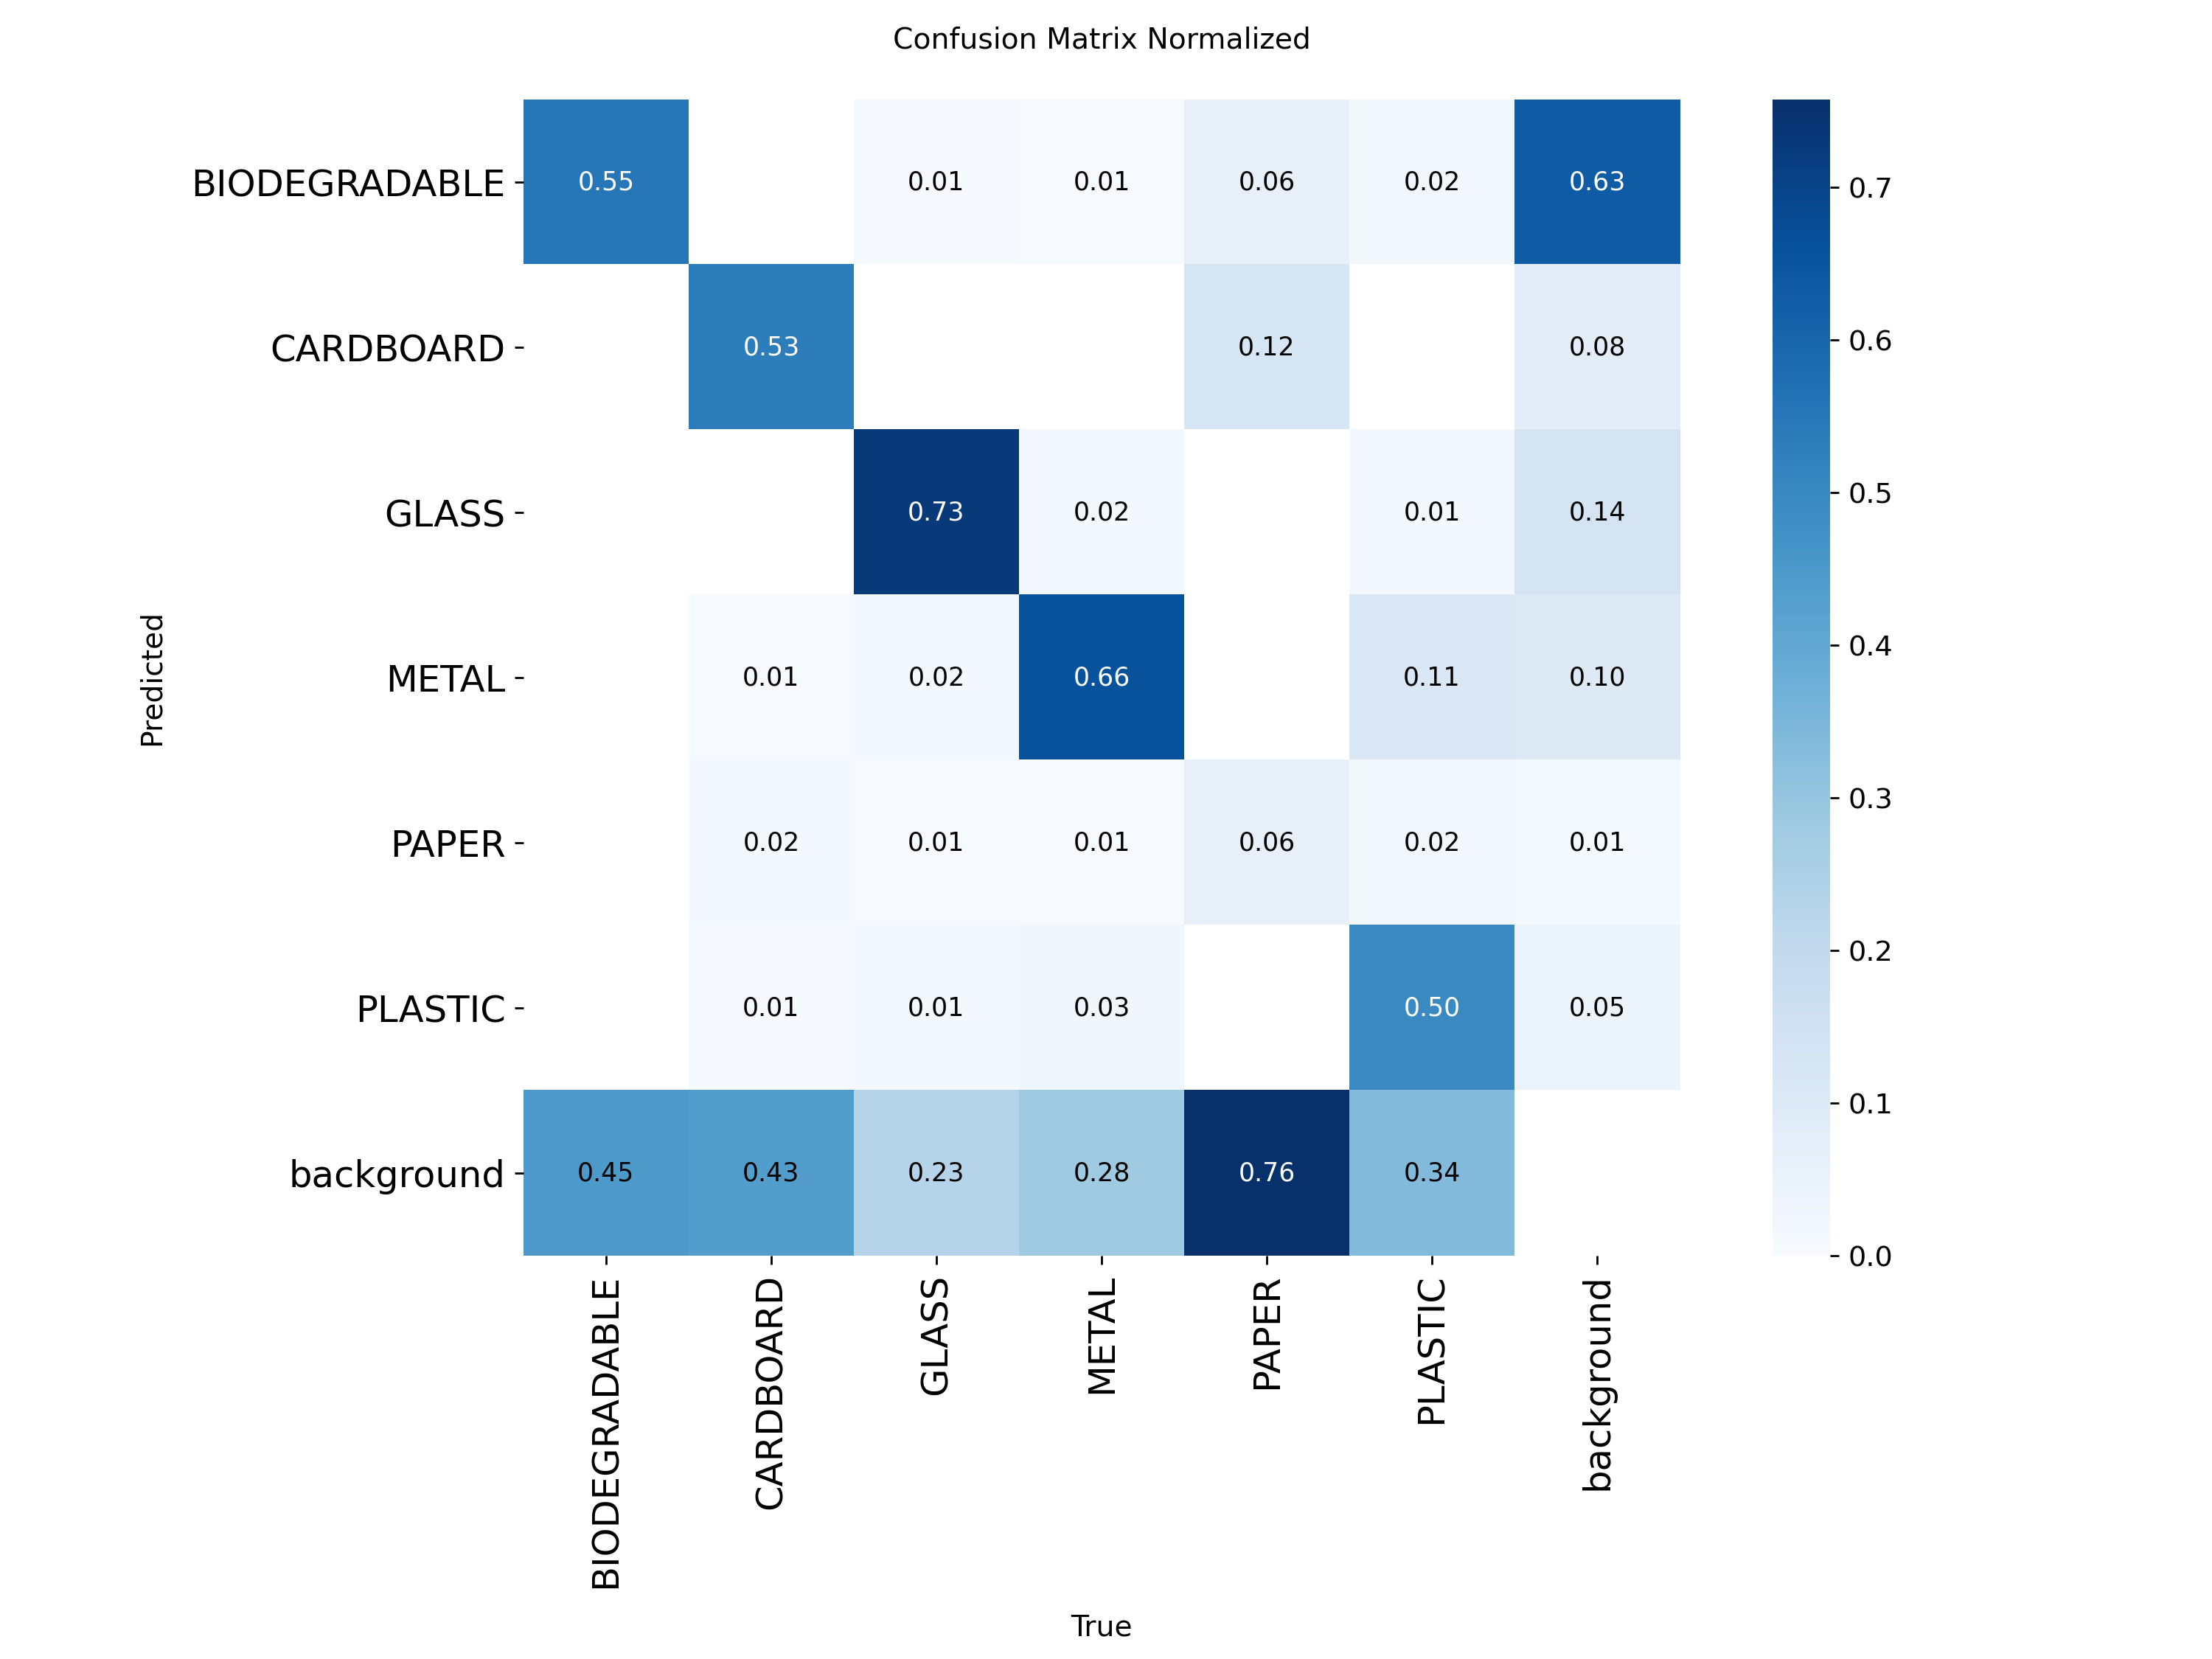


⚠️ Could not find F1_curve.png

⚠️ Could not find PR_curve.png

✨ labels.jpg:


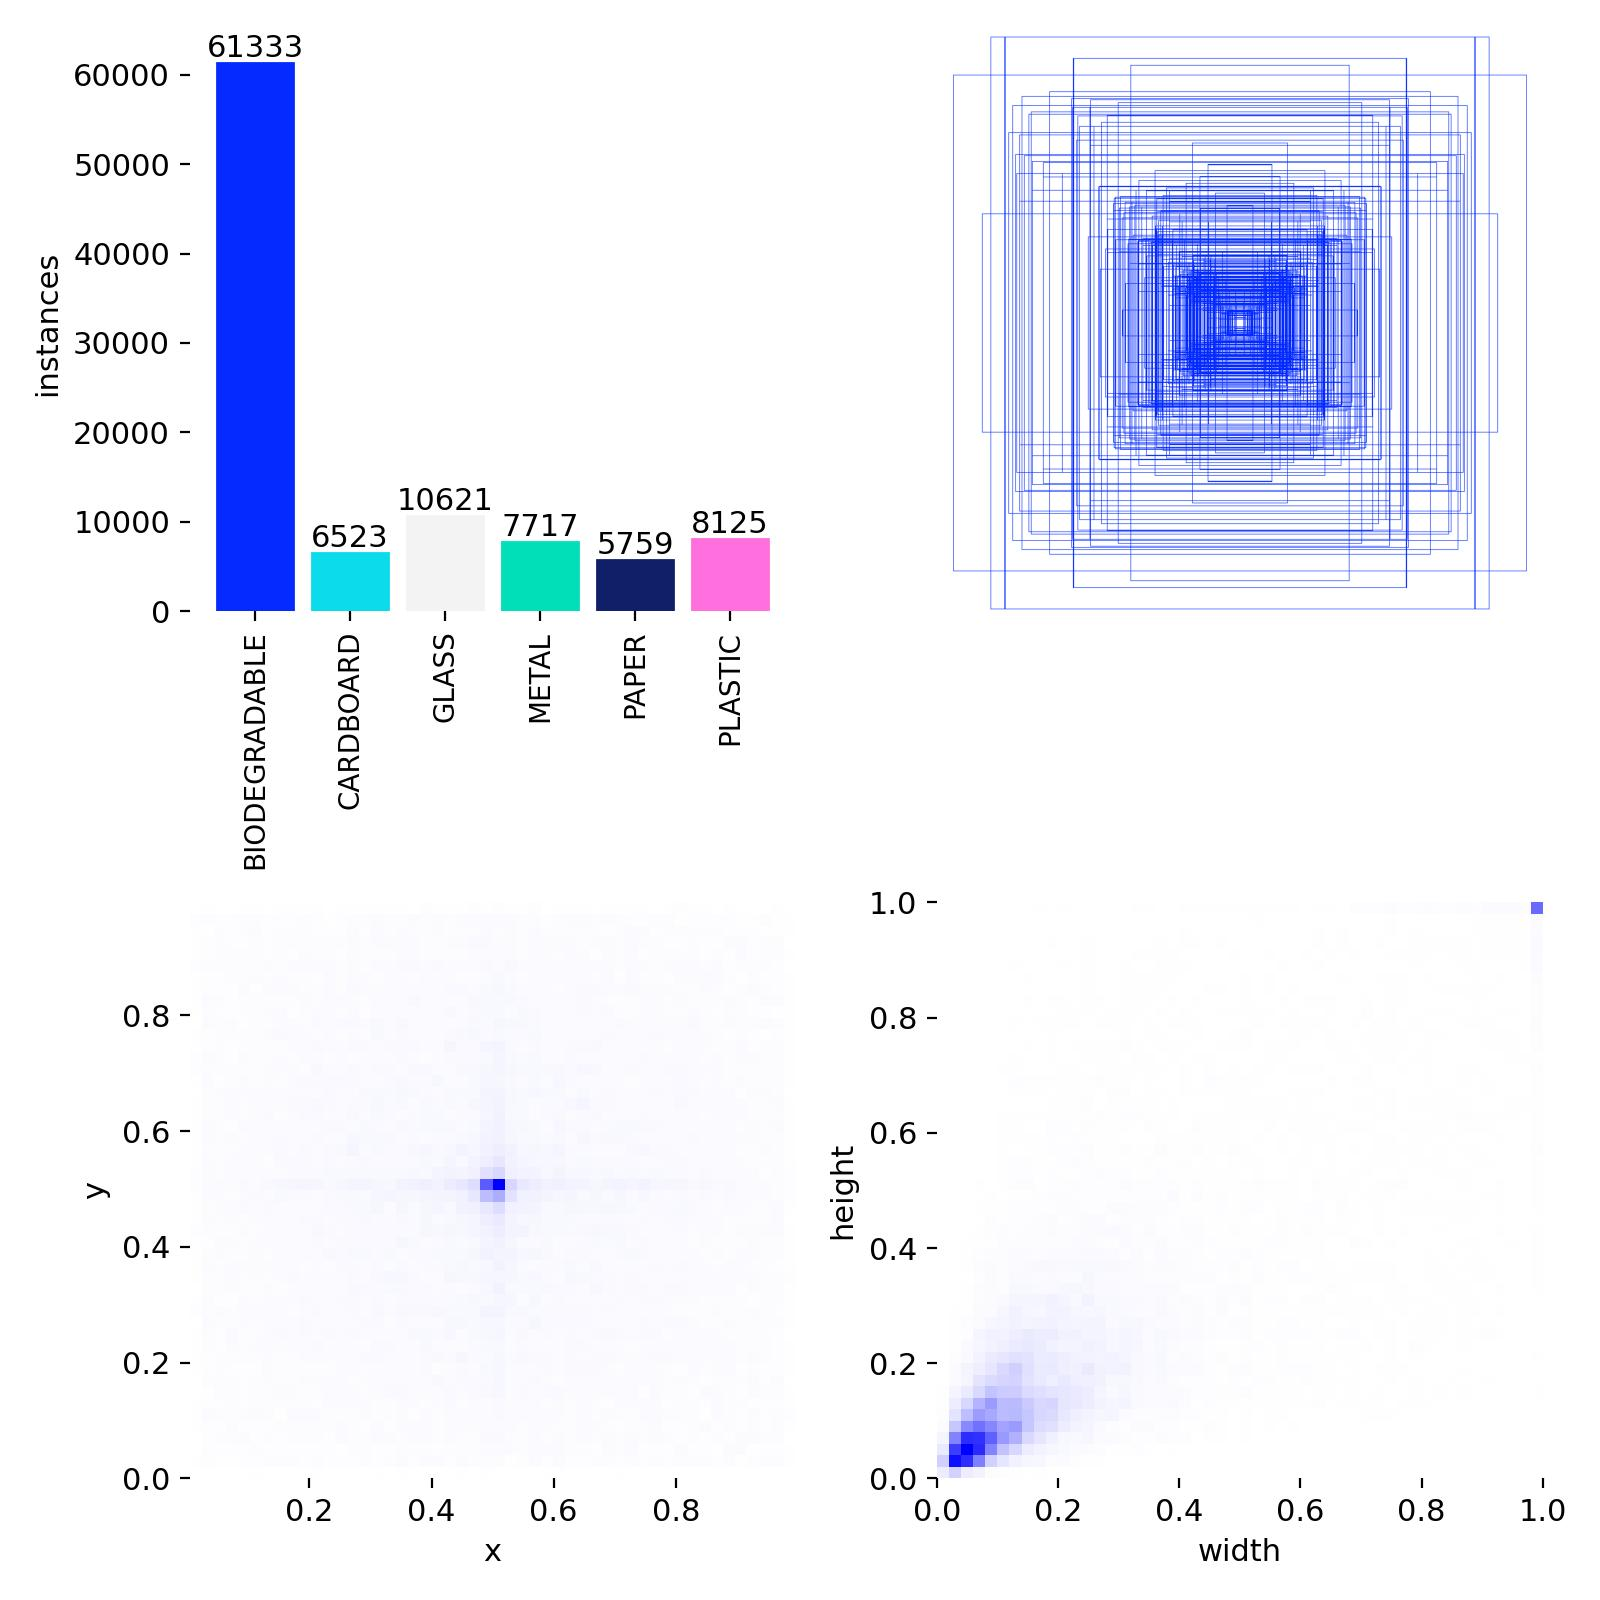


✨ val_batch0_pred.jpg:


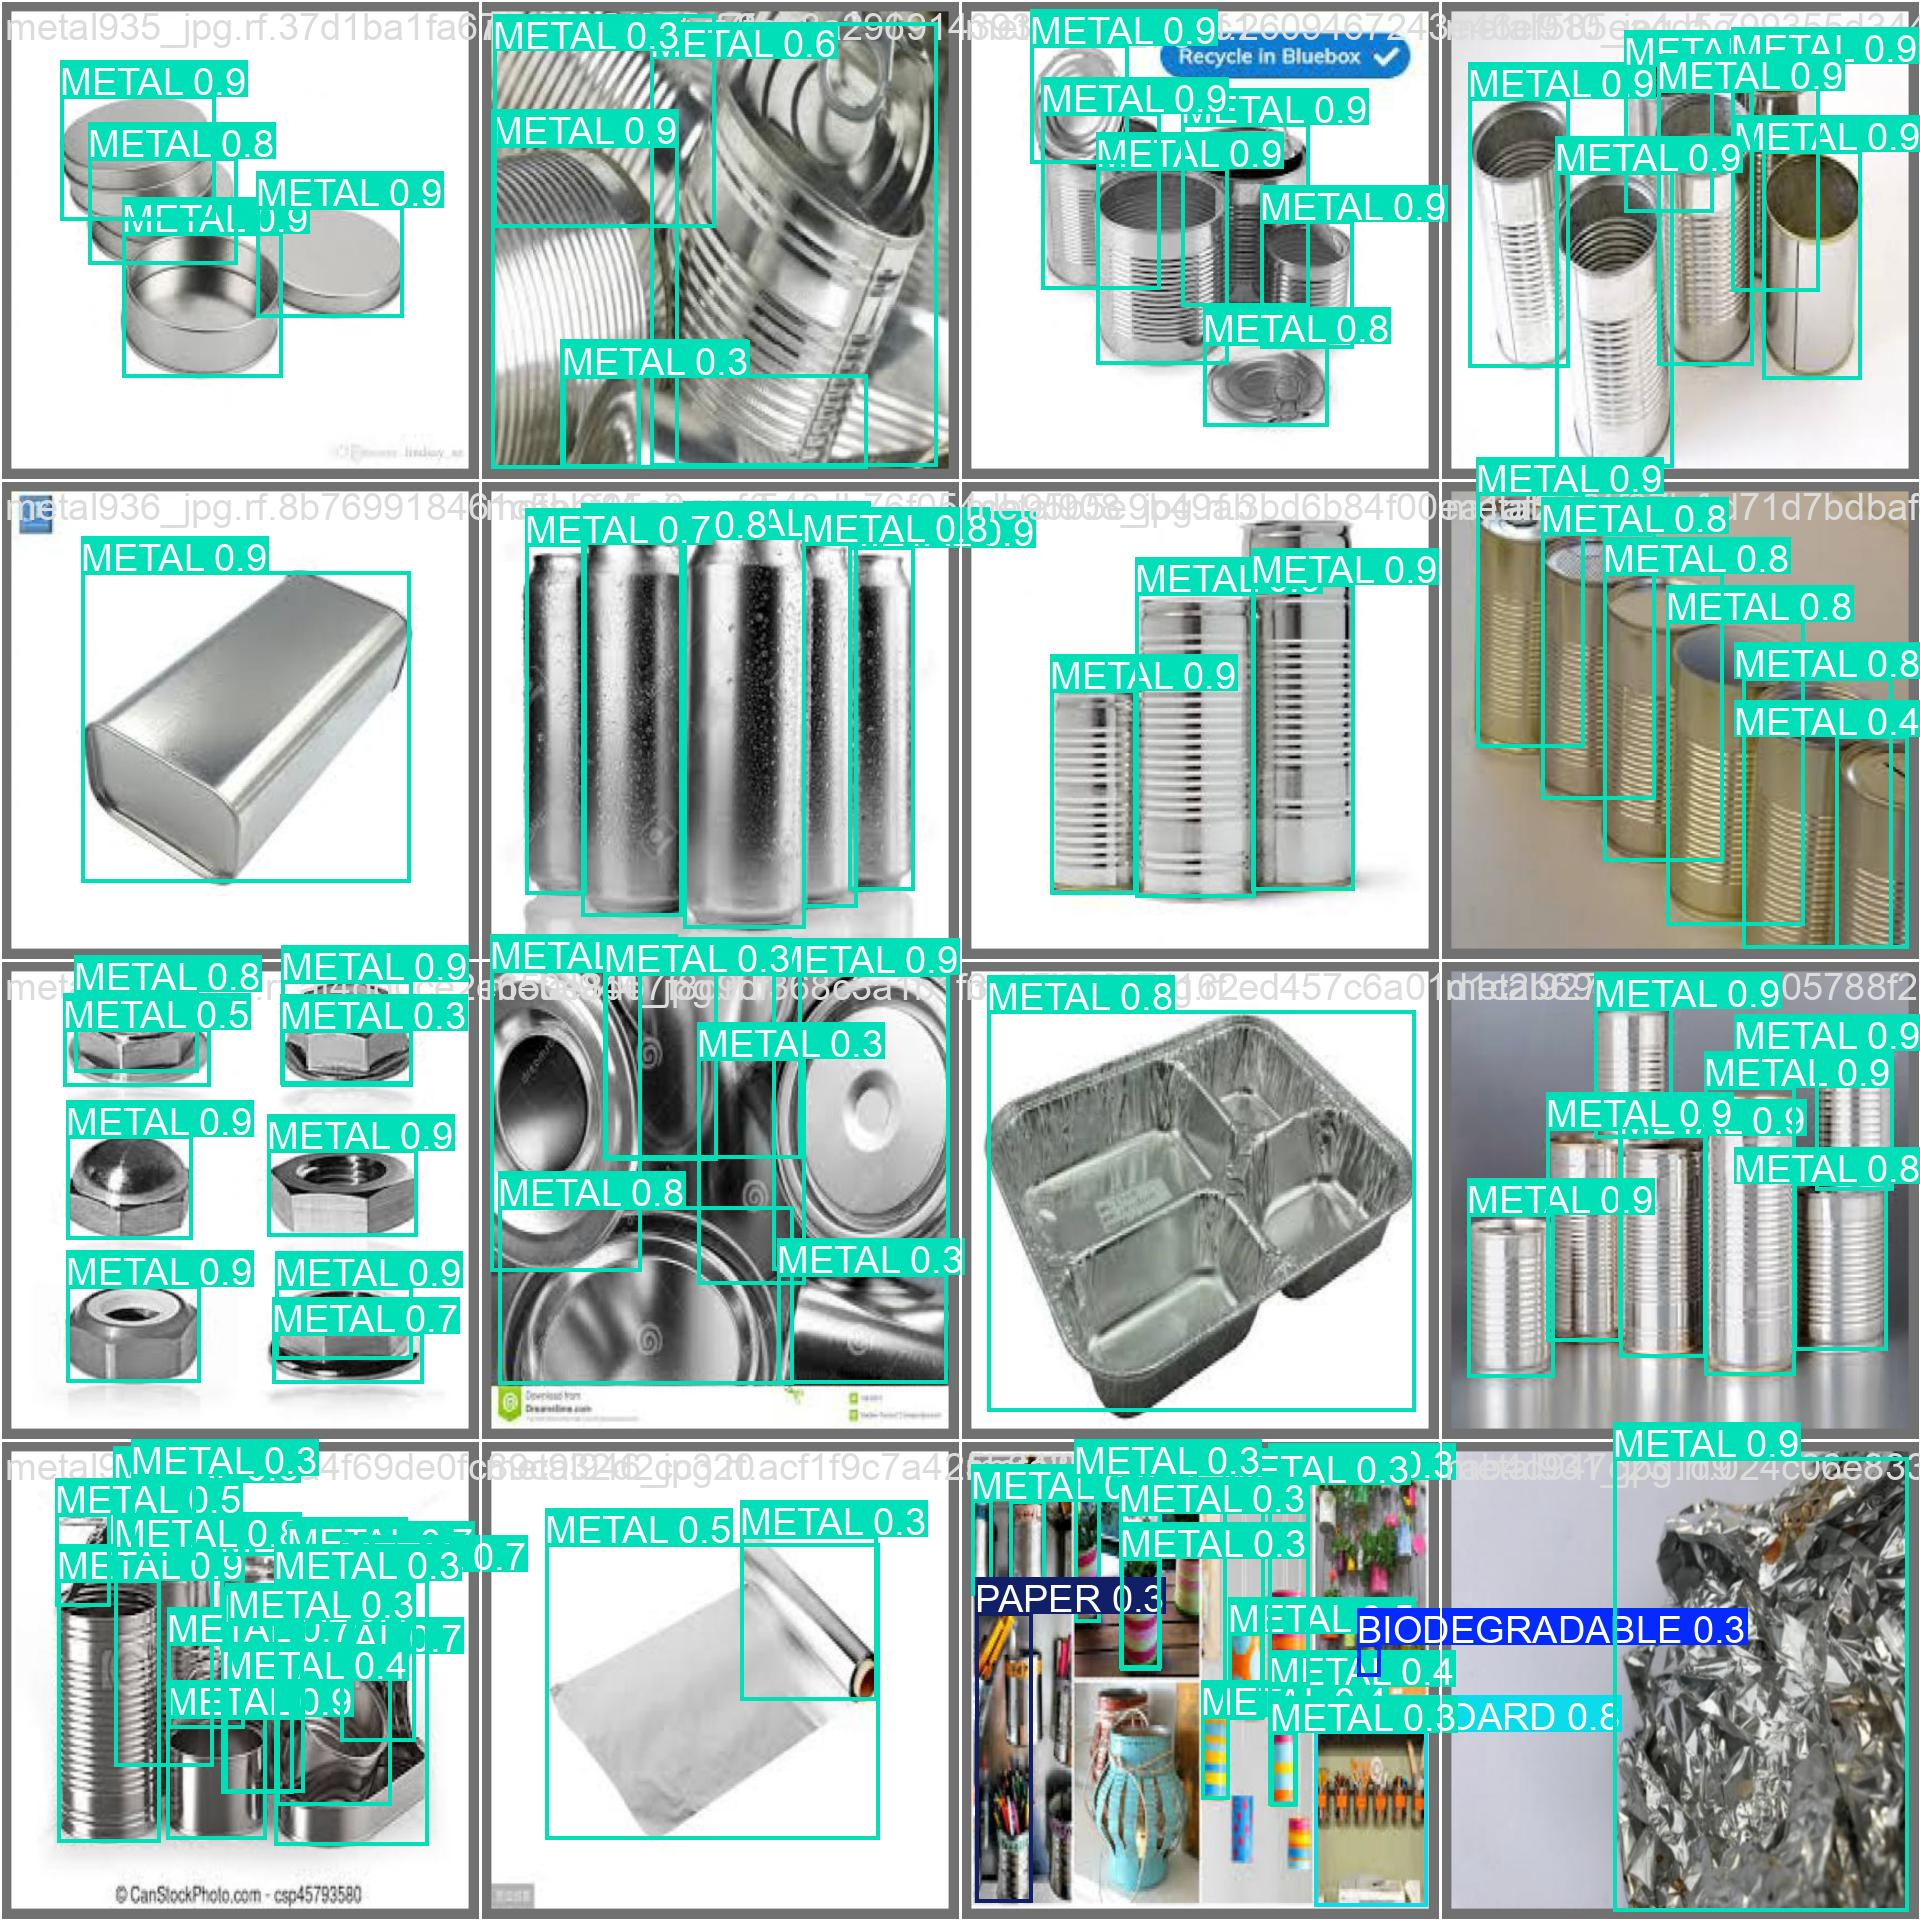

In [19]:
import os
from IPython.display import Image, display

run_dir = "/kaggle/working/runs/detect/Garbage_Detection/run_1"

# A list of the other graphs YOLO generated
graphs_to_download = [
    "confusion_matrix_normalized.png",
]

for graph in extra_graphs:
    filepath = os.path.join(run_dir, graph)
    if os.path.exists(filepath):
        print(f"\n✨ {graph}:")
        display(Image(filename=filepath, width=800))
    else:
        print(f"\n⚠️ Could not find {graph}")

In [ ]:
import os
import glob
import cv2
import random
from ultralytics import YOLO
from IPython.display import Image, display

# 1. Load your newly trained "best" weights
weights_path = "/kaggle/working/runs/detect/Garbage_Detection/run_1/weights/best.pt"
model = YOLO(weights_path)

# 2. Locate the test images folder from your dataset
dataset_path = "/kaggle/input/datasets/jitinvenkatasai/major-project"
test_images_dir = os.path.join(dataset_path, "test", "images") 

# Fallback just in case they are directly in the 'test' folder
if not os.path.exists(test_images_dir):
    test_images_dir = os.path.join(dataset_path, "test")

# Get a list of all the test images (.jpg or .png)
test_images = glob.glob(os.path.join(test_images_dir, "*.jpg")) + glob.glob(os.path.join(test_images_dir, "*.png"))

if len(test_images) == 0:
    print("⚠️ No test images found. Double check the folder path.")
else:
    print(f"✅ Found {len(test_images)} test images! Picking 4 random ones to test...\n")
    
    # 3. Pick 4 random images from the test set
    sample_images = random.sample(test_images, min(4, len(test_images)))
    
    # 4. Run prediction and display them
    for img_path in sample_images:
        print(f"🔍 Testing: {os.path.basename(img_path)}")
        
        # Run YOLO prediction (conf=0.25 means it only shows boxes it is 25%+ sure about)
        results = model.predict(source=img_path, conf=0.25)
        
        # Extract the image with the bounding boxes drawn on it
        res_plot = results[0].plot() 
        
        # Save temporarily and display it
        temp_path = "temp_result.jpg"
        cv2.imwrite(temp_path, res_plot)
        display(Image(filename=temp_path, width=600))